## Run Pipeline

In [1]:
import pandas as pd
from preprocessing import read_srt_in_memory, extract_tokens_with_sentences, isolate_speech
from audio_complexity import extract_complexity, improve_timesteps
from filter_in_out import mark_non_english_in_df, mark_notes_in_df, mark_excluded_words, mark_numbers_in_df
from translation import batch_translate_and_align
from feature_extraction import FeatureExtractor
from model import predict_with_bias, BinaryClassifier
from subtitle_generation import create_srt_file
from utils import device
from types import SimpleNamespace
import torch
import wandb
import time

Using device: cuda


c:\Users\kilia\Documents\intelligent-subtitlesOLD\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
def pipeline(name):    
    reference_file = 'data/' + name + '.srt'
    audio_file = 'data/' + name + '.mp4'
    srt_lines_in_memory = read_srt_in_memory(reference_file)
    original_tokens = extract_tokens_with_sentences(srt_lines_in_memory)
    audio_complexity_results = extract_complexity(audio_file, original_tokens, device=str(device), batch_size=16) # Device-String
    df = pd.DataFrame(audio_complexity_results)
    df['position'] = [token['position'] for token in original_tokens]
    df['sentence'] = [token['sentence'] for token in original_tokens]
    isolate_speech(audio_file, device=str(device))
    print("Isolating speech done")
    print("Improving timesteps...")
    aligned_results = improve_timesteps("data/" + name + "_vocals.wav", df, device=str(device), batch_size=16)
    df['start_time'] = [result['start_time'] for result in aligned_results]
    df['end_time'] = [result['end_time'] for result in aligned_results]
    df['display'] = None
    df['set_manually'] = False
    df['process'] = True
    print(df.head())
    exception_words = ["i", "no", "so"]
    df = mark_non_english_in_df(df, exception_words)
    df = mark_notes_in_df(df)
    df = mark_excluded_words(df)
    df = mark_numbers_in_df(df)
    translation_results = batch_translate_and_align(df, device=str(device), batch_size=16) 
    df_translations = pd.DataFrame(translation_results)
    df['translation'] = df_translations['german_translation']
    feature_extractor = FeatureExtractor(device=str(device))
    df.loc[df['process'], 'word_occurrence'] = df.loc[df['process'], 'word'].apply(feature_extractor.get_word_occurrence)
    df.loc[df['process'], 'word_complexity'] = df.loc[df['process'], 'word'].apply(feature_extractor.get_word_complexity)
    df_sentence_complexity = feature_extractor.get_sentence_complexity(df)
    df["sentence_complexity"] = df_sentence_complexity["sentence_complexity"]
    word_importances = feature_extractor.get_word_importance(df, batch_size=32)
    df["word_importance"] = word_importances
    df = feature_extractor.get_sentence_speed(df)
    df = feature_extractor.get_sentence_speech_volume(df, name)
    df = feature_extractor.get_word_ambient_volume(df, name)
    df = feature_extractor.get_word_frequency(df)
    print(df.head())
    #df.to_csv('data/' + name + '_processed.csv', index=False)


In [ ]:
name = "test"
pipeline(name)

## Training

In [1]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score, classification_report, balanced_accuracy_score, roc_auc_score, recall_score, fbeta_score
from sklearn.model_selection import train_test_split
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
import numpy as np
import matplotlib.pyplot as plt
import torch
import os
import pandas as pd
import wandb

In [ ]:
file_names = ['boysS2E6', 'boysS2E7', 'boysS2E8', 'modernfamilys11e10_labeled_kilian', 'modernfamilys11e11_labeled_kilian', 'modernfamilys9e14_labeled_miriam','modernfamilys9e14_labeled_susanne', 'modernfamilys11e10_labeled_martin', 'modernfamilys11e11_labeled_martin', 'modernfamilys11e11_labeled_silas', 'modernfamilys11e14_labeled_tom', 'modernfamilys11e11_labeled_bernhard', 'modernfamilys11e15_labeled_josef', 'modernfamilys11e11_labeled_gert', 'modernfamilys11e13_labeled_maria']

dfs = []
for file_name in file_names:
    df_temp = pd.read_csv(f"dataset/{file_name}.csv")
    dfs.append(df_temp)

df = pd.concat(dfs, ignore_index=True)
df

,Unnamed: 0.1,Unnamed: 0,word,audio_complexity,position,sentence,start_time,end_time,set_manually,process,...,word_importance,sentence_group,speed,speech_volume,ambient_volume,occurrence,display,language_level,audio_level,frequency
0,0.0,0.0,freedom,0.487793,1,Freedom... ...comes at a price.,3.76,4.20,False,True,...,0.999998,1,0.463031,0.882440,0.957304,0.0,False,0.8,1.0,0.60750
1,1.0,1.0,comes,0.264648,2,Freedom... ...comes at a price.,4.20,4.64,False,True,...,0.984596,1,0.463031,0.882440,0.000000,0.0,False,0.8,1.0,0.67000
2,2.0,2.0,at,0.587158,3,Freedom... ...comes at a price.,4.64,4.80,False,True,...,0.993683,1,0.463031,0.882440,0.000000,0.0,False,0.8,1.0,0.83750
3,3.0,3.0,a,0.029785,4,Freedom... ...comes at a price.,4.80,4.84,False,True,...,0.994423,1,0.463031,0.882440,0.000000,0.0,False,0.8,1.0,0.92000
4,4.0,4.0,price,0.002930,5,Freedom... ...comes at a price.,4.84,5.38,False,True,...,0.406250,1,0.463031,0.882440,0.000000,0.0,False,0.8,1.0,0.65375
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41207,NaN,NaN,back,1.000000,3,I'll be back!,1275.44,1275.64,False,True,...,0.123535,563,0.793882,0.393247,0.000000,NaN,False,1.0,1.0,0.75500
41208,NaN,NaN,it's,0.185547,1,It's not your fault.,1276.26,1276.80,False,True,...,0.197754,564,0.196336,0.318885,0.090837,NaN,False,1.0,1.0,0.79125
41209,NaN,NaN,not,0.004395,2,It's not your fault.,1276.80,1276.94,False,True,...,0.356934,564,0.196336,0.318885,0.000000,NaN,False,1.0,1.0,0.83625
41210,NaN,NaN,your,0.004883,3,It's not your fault.,1276.94,1277.08,False,True,...,0.318359,564,0.196336,0.318885,0.000000,NaN,False,1.0,1.0,0.81625


In [3]:
df = df[df['set_manually'] == False]
df = df[['word', 'audio_complexity', 'word_occurrence', 'word_complexity', 'sentence_complexity', 'word_importance', 'speed', 'speech_volume', 'ambient_volume', 'frequency', 'display', 'audio_level', 'language_level']]
df

,word,audio_complexity,word_occurrence,word_complexity,sentence_complexity,word_importance,speed,speech_volume,ambient_volume,frequency,display,audio_level,language_level
0,freedom,0.487793,0.000000,0.2,0.548678,0.999998,0.463031,0.882440,0.957304,0.60750,False,1.0,0.8
1,comes,0.264648,0.000000,0.0,0.548678,0.984596,0.463031,0.882440,0.000000,0.67000,False,1.0,0.8
2,at,0.587158,0.000000,0.0,0.548678,0.993683,0.463031,0.882440,0.000000,0.83750,False,1.0,0.8
3,a,0.029785,0.000000,0.0,0.548678,0.994423,0.463031,0.882440,0.000000,0.92000,False,1.0,0.8
4,price,0.002930,0.000000,0.2,0.548678,0.406250,0.463031,0.882440,0.000000,0.65375,False,1.0,0.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...
41207,back,1.000000,0.857143,0.2,0.448872,0.123535,0.793882,0.393247,0.000000,0.75500,False,1.0,1.0
41208,it's,0.185547,1.000000,0.0,0.479681,0.197754,0.196336,0.318885,0.090837,0.79125,False,1.0,1.0
41209,not,0.004395,1.000000,0.0,0.479681,0.356934,0.196336,0.318885,0.000000,0.83625,False,1.0,1.0
41210,your,0.004883,1.000000,0.0,0.479681,0.318359,0.196336,0.318885,0.000000,0.81625,False,1.0,1.0


In [5]:
from sklearn.model_selection import train_test_split

# Split the data into training and test sets
X = df.drop('display', axis=1)  # Features
y = df['display']  # Target variable

# Split with stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  # 20% for testing
    random_state=42,  # For reproducibility
    stratify=y  # Maintain class distribution
)

# Print sizes
print(f"Total dataset size: {len(df)}")
print(f"Training set size: {len(X_train)} ({len(X_train)/len(df)*100:.1f}%)")
print(f"Test set size: {len(X_test)} ({len(X_test)/len(df)*100:.1f}%)")
# Calculate class imbalance ratio
pos_count = sum(y == True)
neg_count = sum(y == False)
imbalance_ratio = neg_count / pos_count

print(f"\nClass imbalance:")
print(f"Positive examples (display=True): {pos_count}")
print(f"Negative examples (display=False): {neg_count}")
print(f"Imbalance ratio (negative:positive): {imbalance_ratio:.2f}:1")

# Check data balance in features
print("\nFeature statistics by class:")
for feature in ['audio_complexity', 'word_complexity', 'word_importance', 'speech_volume']:
    pos_mean = X_train.loc[y_train == True, feature].mean()
    neg_mean = X_train.loc[y_train == False, feature].mean()
    print(f"  {feature}: True={pos_mean:.4f}, False={neg_mean:.4f}, Difference={abs(pos_mean-neg_mean):.4f}")
# Print class distribution in original and split datasets
print("\nClass distribution:")
print(f"Original - Displayed: {sum(y == True)} ({sum(y == True)/len(y)*100:.1f}%)")
print(f"Training - Displayed: {sum(y_train == True)} ({sum(y_train == True)/len(y_train)*100:.1f}%)")
print(f"Test - Displayed: {sum(y_test == True)} ({sum(y_test == True)/len(y_test)*100:.1f}%)")

# Add this code to a new cell after the cell with id 'a6d108d5'

# --- Data Statistics ---
total_size = len(df)
train_size = len(X_train)
test_size = len(X_test)
display_true_count = df['display'].sum()

print(f"--- Dataset Statistics ---")
print(f"Total dataset size: {total_size} words")
print(f"Training set size: {train_size} words ({train_size/total_size*100:.1f}%)")
print(f"Test set size: {test_size} words ({test_size/total_size*100:.1f}%)")
print(f"Number of words marked for display (display=True): {display_true_count} ({display_true_count/total_size*100:.1f}%)")

# --- CEFR Level Combinations ---
cefr_levels = {
    'A1': 0.0,
    'A2': 0.2,
    'B1': 0.4,
    'B2': 0.6,
    'C1': 0.8,
    'C2': 1.0
}
# Create an inverse mapping from numeric value to CEFR label
numeric_to_cefr = {v: k for k, v in cefr_levels.items()}

print(f"\n--- Word Counts per CEFR Level Combination ---")
# Group by audio and language levels and count occurrences
level_counts = df.groupby(['audio_level', 'language_level']).size().reset_index(name='count')

# Print the counts using CEFR labels
for index, row in level_counts.iterrows():
    audio_level_numeric = row['audio_level']
    language_level_numeric = row['language_level']
    count = row['count']

    # Map numeric levels to CEFR labels, handle potential missing keys if necessary
    audio_cefr = numeric_to_cefr.get(audio_level_numeric, f"Unknown ({audio_level_numeric})")
    language_cefr = numeric_to_cefr.get(language_level_numeric, f"Unknown ({language_level_numeric})")

    print(f"Audio Level: {audio_cefr}, Language Level: {language_cefr} -> {count} words")


Total dataset size: 39367
Training set size: 31493 (80.0%)
Test set size: 7874 (20.0%)

Class imbalance:
Positive examples (display=True): 3416
Negative examples (display=False): 35951
Imbalance ratio (negative:positive): 10.52:1

Feature statistics by class:
  audio_complexity: True=0.4072, False=0.2892, Difference=0.1179
  word_complexity: True=0.3023, False=0.1064, Difference=0.1959
  word_importance: True=0.6054, False=0.5310, Difference=0.0744
  speech_volume: True=0.4820, False=0.4929, Difference=0.0109

Class distribution:
Original - Displayed: 3416 (8.7%)
Training - Displayed: 2733 (8.7%)
Test - Displayed: 683 (8.7%)
--- Dataset Statistics ---
Total dataset size: 39367 words
Training set size: 31493 words (80.0%)
Test set size: 7874 words (20.0%)
Number of words marked for display (display=True): 3416 (8.7%)

--- Word Counts per CEFR Level Combination ---
Audio Level: B2, Language Level: B1 -> 6629.0 words
Audio Level: B2, Language Level: B2 -> 3507.0 words
Audio Level: C2, Lan

### Gradient Boosting

In [ ]:
import wandb
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import fbeta_score, classification_report, average_precision_score
import numpy as np

# Define the sweep configuration with model hyperparameters and feature toggles.
sweep_config = {
    'method': 'random',
    'metric': {
        'name': 'val_aucpr',
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {'min': 0.001, 'max': 0.2, 'distribution': 'uniform'},
        'max_depth': {'values': [3, 4, 5, 6, 7]},
        'subsample': {'min': 0.6, 'max': 1.0, 'distribution': 'uniform'},
        'colsample_bytree': {'min': 0.6, 'max': 1.0, 'distribution': 'uniform'},
        'reg_lambda': {'min': 0.1, 'max': 10.0, 'distribution': 'uniform'},
        'gamma': {'min': 0.0, 'max': 5.0, 'distribution': 'uniform'},
        'min_child_weight': {'min': 1.0, 'max': 10.0, 'distribution': 'uniform'},
        'scale_pos_weight': {'min': 0.5, 'max': 2.0, 'distribution': 'uniform'},
        # Feature toggles: if True the corresponding feature is included
        'audio_complexity': {'values': [True, False]},
        'word_occurrence': {'values': [True, False]},
        'word_complexity': {'values': [True, False]},
        'sentence_complexity': {'values': [True, False]},
        'word_importance': {'values': [True, False]},
        'speed': {'values': [True, False]},
        'ambient_volume': {'values': [True, False]},
        'speech_volume': {'values': [True, False]},
        'frequency': {'values': [True, False]},
        'audio_level': {'values': [True, False]},
        'language_level': {'values': [True, False]}
    }
}

def train():
    # Initialize a new wandb run with the provided hyperparameters.
    wandb.init(project="XGBoost-Hyperparameter-Tuning", config=sweep_config["parameters"])
    
    # Dynamically build the feature list based on the feature toggle parameters.
    feature_flags = {
        'audio_complexity': wandb.config.audio_complexity,
        'word_occurrence': wandb.config.word_occurrence,
        'word_complexity': wandb.config.word_complexity,
        'sentence_complexity': wandb.config.sentence_complexity,
        'word_importance': wandb.config.word_importance,
        'speed': wandb.config.speed,
        'ambient_volume': wandb.config.ambient_volume,
        'speech_volume': wandb.config.speech_volume,
        'frequency': wandb.config.frequency,
        'audio_level': wandb.config.audio_level,
        'language_level': wandb.config.language_level
    }
    
    # Build the final features list; if none are selected, use all the features.
    features = [feat for feat, include in feature_flags.items() if include]
    if not features:
        features = list(feature_flags.keys())
    
    target = 'display'
    
    # Extract features and target; df is assumed to be already loaded.
    X = df[features]
    y = df[target]
    
    # Compute class imbalance weight.
    neg_count = (y == 0).sum()
    pos_count = (y == 1).sum()
    base_scale_pos = neg_count / pos_count if pos_count > 0 else 1
    
    # Split the dataset into training and validation sets (80/20 split, stratified).
    X_train, X_val, y_train, y_val = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )
    
    # Initialize the XGBoost classifier, setting evaluation metric as 'aucpr'.
    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='aucpr',
        n_estimators=1000,
        early_stopping_rounds=50,
        use_label_encoder=False,
        learning_rate=wandb.config.learning_rate,
        max_depth=wandb.config.max_depth,
        subsample=wandb.config.subsample,
        colsample_bytree=wandb.config.colsample_bytree,
        reg_lambda=wandb.config.reg_lambda,
        gamma=wandb.config.gamma,
        min_child_weight=wandb.config.min_child_weight,
        scale_pos_weight=base_scale_pos * wandb.config.scale_pos_weight,
        verbosity=0
    )
    
    # Train the model with early stopping on the validation set.
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        verbose=False
    )
    
    # Generate predictions and probability estimates from the validation set.
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    
    # Calculate the F2 score.
    f2 = fbeta_score(y_val, y_pred, beta=2)
    
    # Get the final AUC PR score from the evaluation results; if unavailable, compute using average_precision_score.
    evals_result = model.evals_result()
    if 'aucpr' in evals_result.get('validation_0', {}):
        aucpr = evals_result['validation_0']['aucpr'][-1]
    else:
        aucpr = average_precision_score(y_val, y_proba)
    
    # Generate a detailed classification report.
    cls_report = classification_report(y_val, y_pred, output_dict=True)
    
    # Log all relevant metrics and configuration details to wandb.
    wandb.log({
        'val_f2': f2,
        'val_aucpr': aucpr,
        'features_used': features,
        'classification_report': cls_report,
    })
    
    # Print the classification report to console.
    print("Classification Report:")
    print(classification_report(y_val, y_pred))
    
    wandb.finish()

# Setup and run the wandb sweep agent.
sweep_id = wandb.sweep(sweep_config, project="XGBoost-Hyperparameter-Tuning2")
wandb.agent(sweep_id, function=train, count=5000)


#### Retrain model configuration

In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import fbeta_score, classification_report, average_precision_score, f1_score, balanced_accuracy_score, roc_auc_score # Added f1_score, balanced_accuracy_score, roc_auc_score
import matplotlib.pyplot as plt

# Define the features based on the optimal configuration found in the sweep
feature_flags = {
    'audio_complexity': True,
    'word_occurrence': True, 
    'word_complexity': True,
    'sentence_complexity': True,
    'word_importance': True,
    'speed': True,
    'ambient_volume': True,
    'speech_volume': True,
    'frequency': True,
    'audio_level': True,
    'language_level': True
}

# Build the feature list based on enabled flags
features = [feat for feat, include in feature_flags.items() if include]
print(f"Using features: {features}")

target = 'display'

# Extract features and target
X = df[features]
y = df[target]

# Compute class imbalance weight
neg_count = (y == 0).sum()
pos_count = (y == 1).sum()
base_scale_pos = neg_count / pos_count if pos_count > 0 else 1
print(f"Class distribution - Neg: {neg_count}, Pos: {pos_count}")
print(f"Base scale_pos_weight: {base_scale_pos:.4f}")

# Split the dataset into training and test sets (80/20 split, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Initialize the XGBoost classifier with the optimal hyperparameters
model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='aucpr',
    n_estimators=1000,
    early_stopping_rounds=50,
    use_label_encoder=False,
    # Optimal hyperparameters from the sweep
    learning_rate=0.13992233340840426,
    max_depth=7,
    subsample=0.9232242407097228,
    colsample_bytree=0.7193752722179043,
    reg_lambda=7.951383350876875,
    gamma=2.3445839476786774,
    min_child_weight=6.480095320459142,
    scale_pos_weight=base_scale_pos * 1.7470312344571224,
    verbosity=1,
    random_state=42,
)

print("\nTraining model with optimal hyperparameters...")
# Train the model with early stopping on the test set
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=True
)

print(f"Best iteration: {model.best_iteration}")

# Generate predictions and probability estimates
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Calculate the F2 score
f2 = fbeta_score(y_test, y_pred, beta=2)
# Calculate F1 score
f1 = f1_score(y_test, y_pred) # Added F1 score calculation
# Calculate Balanced Accuracy
bacc = balanced_accuracy_score(y_test, y_pred) # Added Balanced Accuracy calculation


print(f"\nModel Performance:")
print(f"F2 Score: {f2:.4f}")
print(f"F1 Score: {f1:.4f}") # Added F1 score print
print(f"Balanced Accuracy: {bacc:.4f}") # Added Balanced Accuracy print
print(f"ROC-AUC: {roc_auc:.4f}")

# Generate classification report
print("\nClassification Report:")
cls_report = classification_report(y_test, y_pred)
print(cls_report)

# Feature importance analysis
importance = model.feature_importances_
indices = np.argsort(importance)[::-1]

print("\nFeature Importance:")
for i, idx in enumerate(indices):
    print(f"{features[idx]}: {importance[idx]:.4f}")

# Save the model
model.save_model('gradient_boosting.json')
print("Model saved as 'gradient_boosting.json'")


Using features: ['audio_complexity', 'word_occurrence', 'word_complexity', 'sentence_complexity', 'word_importance', 'speed', 'ambient_volume', 'speech_volume', 'frequency', 'audio_level', 'language_level']
Class distribution - Neg: 35951, Pos: 3416
Base scale_pos_weight: 10.5243
Training set: 31493 samples
Test set: 7874 samples

Training model with optimal hyperparameters...
[0]	validation_0-aucpr:0.31484
[1]	validation_0-aucpr:0.34598
[2]	validation_0-aucpr:0.36009
[3]	validation_0-aucpr:0.36848
[4]	validation_0-aucpr:0.36683
[5]	validation_0-aucpr:0.37918
[6]	validation_0-aucpr:0.38198
[7]	validation_0-aucpr:0.38074
[8]	validation_0-aucpr:0.38463
[9]	validation_0-aucpr:0.38970


c:\Users\kilia\Documents\intelligent-subtitlesOLD\.venv\Lib\site-packages\xgboost\callback.py:386: UserWarning: [20:10:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  self.starting_round = model.num_boosted_rounds()


[10]	validation_0-aucpr:0.38831
[11]	validation_0-aucpr:0.39131
[12]	validation_0-aucpr:0.38874
[13]	validation_0-aucpr:0.39128
[14]	validation_0-aucpr:0.39135
[15]	validation_0-aucpr:0.39709
[16]	validation_0-aucpr:0.39755
[17]	validation_0-aucpr:0.40425
[18]	validation_0-aucpr:0.40728
[19]	validation_0-aucpr:0.40800
[20]	validation_0-aucpr:0.40859
[21]	validation_0-aucpr:0.40902
[22]	validation_0-aucpr:0.41213
[23]	validation_0-aucpr:0.41172
[24]	validation_0-aucpr:0.41502
[25]	validation_0-aucpr:0.41850
[26]	validation_0-aucpr:0.42067
[27]	validation_0-aucpr:0.42284
[28]	validation_0-aucpr:0.42310
[29]	validation_0-aucpr:0.42240
[30]	validation_0-aucpr:0.42402
[31]	validation_0-aucpr:0.42585
[32]	validation_0-aucpr:0.42649
[33]	validation_0-aucpr:0.42529
[34]	validation_0-aucpr:0.42666
[35]	validation_0-aucpr:0.43118
[36]	validation_0-aucpr:0.43080
[37]	validation_0-aucpr:0.43008
[38]	validation_0-aucpr:0.43275
[39]	validation_0-aucpr:0.43265
[40]	validation_0-aucpr:0.43402
[41]	val

## Training data size

Using features: ['audio_complexity', 'word_occurrence', 'word_complexity', 'sentence_complexity', 'word_importance', 'speed', 'ambient_volume', 'speech_volume', 'frequency', 'audio_level', 'language_level']

--- Starting Training Size Evaluation ---

Evaluating with Training Size: 0.1 (Test Size: 0.9)
  Training set size: 3936 samples
  Test set size: 35431 samples
  Class distribution (Train) - Neg: 3594, Pos: 342
  Current scale_pos_weight: 10.5088
  Validation F2 Score: 0.4850

Evaluating with Training Size: 0.2 (Test Size: 0.8)
  Training set size: 7873 samples
  Test set size: 31494 samples
  Class distribution (Train) - Neg: 7190, Pos: 683
  Current scale_pos_weight: 10.5271
  Validation F2 Score: 0.5163

Evaluating with Training Size: 0.3 (Test Size: 0.7)
  Training set size: 11810 samples
  Test set size: 27557 samples
  Class distribution (Train) - Neg: 10785, Pos: 1025
  Current scale_pos_weight: 10.5220
  Validation F2 Score: 0.5280

Evaluating with Training Size: 0.4 (Test 

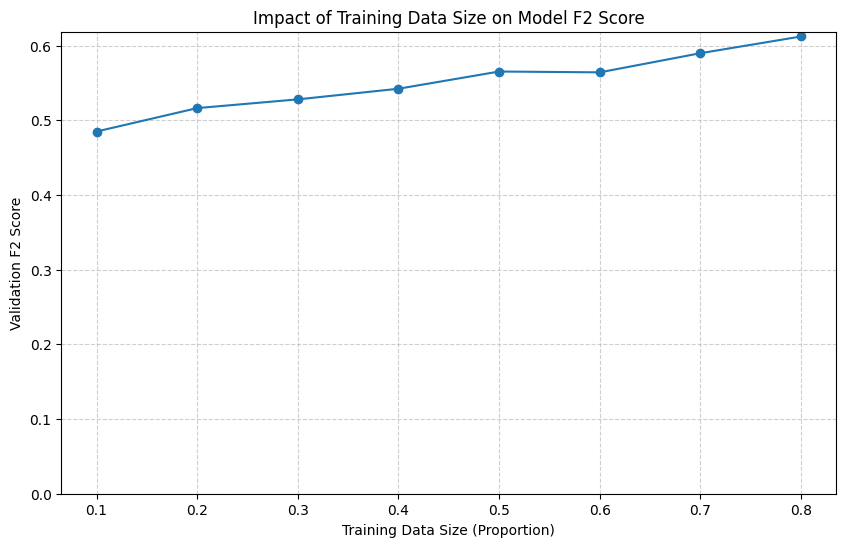

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import fbeta_score, classification_report, f1_score, balanced_accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import wandb # Assuming wandb might be used for logging, though not explicitly requested for each run here

# Define the features based on the optimal configuration found in the sweep
feature_flags = {
    'audio_complexity': True,
    'word_occurrence': True,
    'word_complexity': True,
    'sentence_complexity': True,
    'word_importance': True,
    'speed': True,
    'ambient_volume': True,
    'speech_volume': True,
    'frequency': True,
    'audio_level': True,
    'language_level': True
}

# Build the feature list based on enabled flags
features = [feat for feat, include in feature_flags.items() if include]
print(f"Using features: {features}")

target = 'display'

# Extract features and target from the full dataset
X_full = df[features]
y_full = df[target]

# Define the range of test sizes (which implies training sizes)
test_sizes = [0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2]
results = {} # To store training_size: f2_score

print("\n--- Starting Training Size Evaluation ---")

for test_size in test_sizes:
    train_size = 1.0 - test_size
    print(f"\nEvaluating with Training Size: {train_size:.1f} (Test Size: {test_size:.1f})")

    # Split the dataset into training and test sets for the current size
    X_train, X_test, y_train, y_test = train_test_split(
        X_full, y_full, test_size=test_size, stratify=y_full, random_state=42
    )

    print(f"  Training set size: {X_train.shape[0]} samples")
    print(f"  Test set size: {X_test.shape[0]} samples")

    # Compute class imbalance weight *for the current training set*
    neg_count_train = (y_train == 0).sum()
    pos_count_train = (y_train == 1).sum()

    # Handle potential division by zero if one class is missing in the small training set
    if pos_count_train > 0:
        current_scale_pos_weight = neg_count_train / pos_count_train
    else:
        print("  Warning: No positive samples in the current training set. Setting scale_pos_weight to 1.")
        current_scale_pos_weight = 1

    print(f"  Class distribution (Train) - Neg: {neg_count_train}, Pos: {pos_count_train}")
    print(f"  Current scale_pos_weight: {current_scale_pos_weight:.4f}")

    # Initialize the XGBoost classifier with the optimal hyperparameters
    # Using the *current* scale_pos_weight
    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='aucpr',
        n_estimators=1000,
        early_stopping_rounds=50,
        use_label_encoder=False,
        # Optimal hyperparameters from the sweep
        learning_rate=0.13992233340840426,
        max_depth=7,
        subsample=0.9232242407097228,
        colsample_bytree=0.7193752722179043,
        reg_lambda=7.951383350876875,
        gamma=2.3445839476786774,
        min_child_weight=6.480095320459142,
        scale_pos_weight=current_scale_pos_weight * 1.7470312344571224, 
        verbosity=0,
        random_state=42
    )

    # Train the model with early stopping on the *current* test set
    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False # Set to False to reduce console output during loop
    )

    # Generate predictions on the *current* test set
    y_pred = model.predict(X_test)

    # Calculate the F2 score for the current test set
    f2 = fbeta_score(y_test, y_pred, beta=2)
    print(f"  Validation F2 Score: {f2:.4f}")

    # Store the result
    results[train_size] = f2

print("\n--- Evaluation Complete ---")

# Print the results
print("\nTraining Size vs. F2 Score:")
for size, score in sorted(results.items()):
    print(f"  Training Size: {size:.1f} -> F2 Score: {score:.4f}")

# Plot the results
train_sizes_list = sorted(results.keys())
f2_scores_list = [results[size] for size in train_sizes_list]

plt.figure(figsize=(10, 6))
plt.plot(train_sizes_list, f2_scores_list, marker='o', linestyle='-')
plt.title('Impact of Training Data Size on Model F2 Score')
plt.xlabel('Training Data Size (Proportion)')
plt.ylabel('Validation F2 Score')
plt.xticks(train_sizes_list) # Ensure ticks are at the tested sizes
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(bottom=0) # F2 score cannot be negative
plt.show()

## Correlation

Correlation between features and display=True:
                     correlation       p_value
audio_complexity        0.080797  5.120454e-58
word_occurrence        -0.199641  0.000000e+00
word_complexity         0.245205  0.000000e+00
sentence_complexity     0.084320  4.830728e-63
word_importance         0.056989  1.091141e-29
speed                   0.004517  3.701660e-01
speech_volume          -0.017123  6.800194e-04
ambient_volume         -0.037136  1.699000e-13
frequency              -0.303183  0.000000e+00
audio_level             0.004650  3.561900e-01
language_level          0.045713  1.143107e-19


C:\Users\kilia\AppData\Local\Temp\ipykernel_41804\3354797000.py:46: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(corr_df['correlation'][i] + 0.01 if corr_df['correlation'][i] >= 0
C:\Users\kilia\AppData\Local\Temp\ipykernel_41804\3354797000.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  else corr_df['correlation'][i] - 0.07, i, significance, va='center')
C:\Users\kilia\AppData\Local\Temp\ipykernel_41804\3354797000.py:53: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To

IndexError: index 8 is out of bounds for axis 0 with size 8

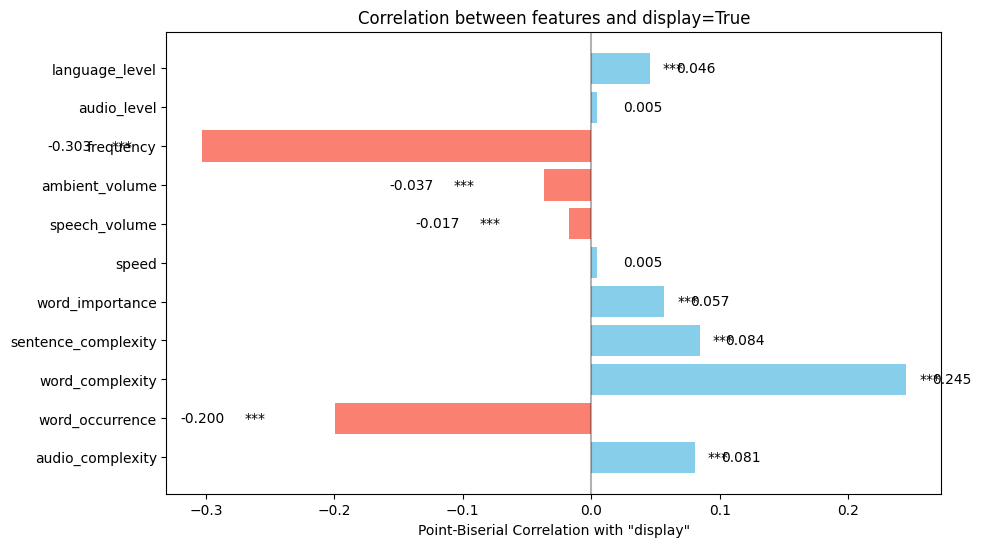

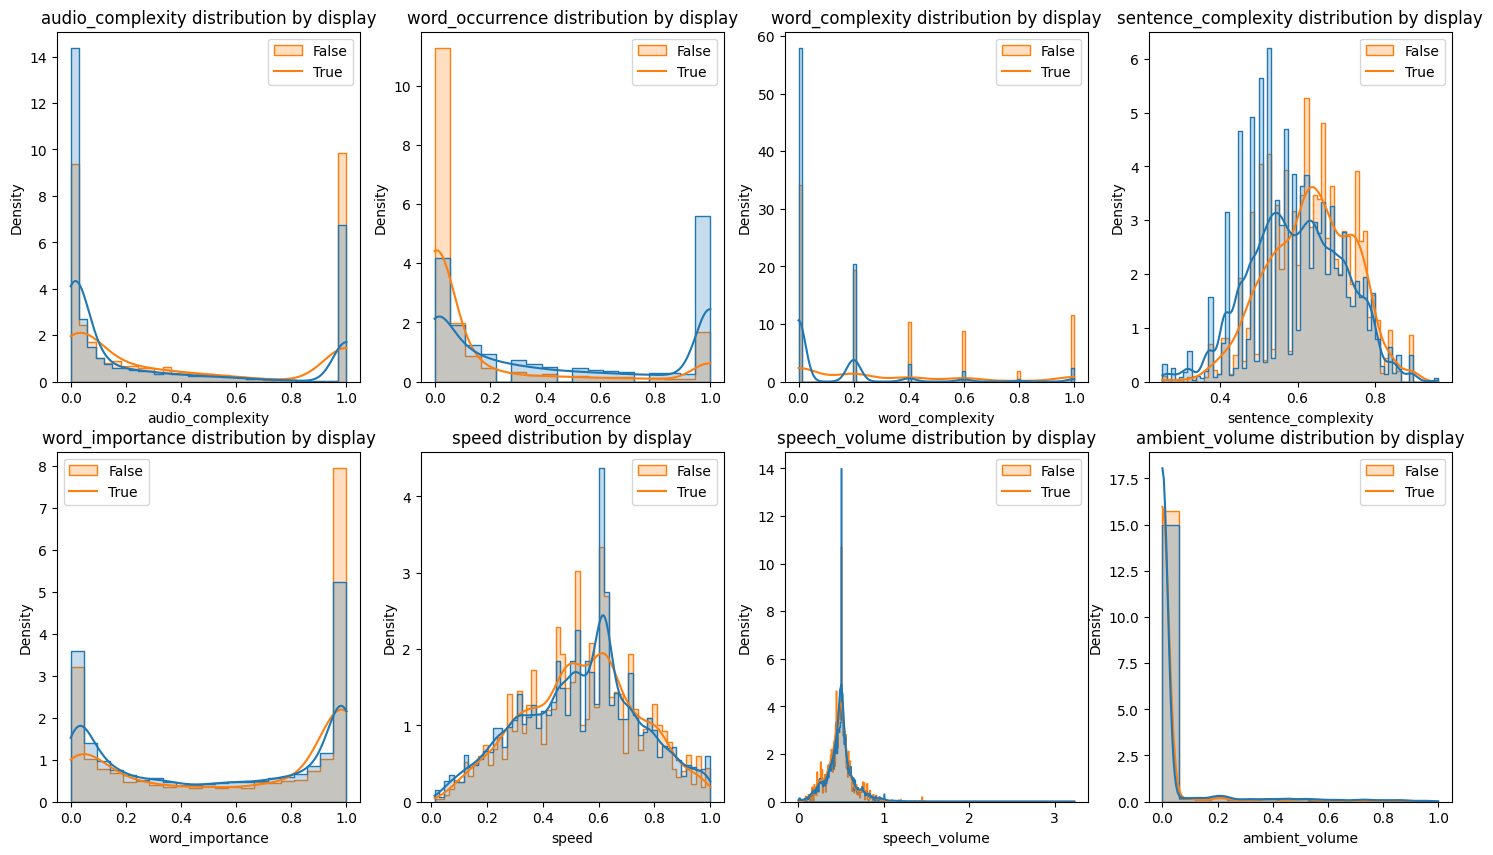

In [11]:
import seaborn as sns
import numpy as np
from scipy.stats import pointbiserialr

import matplotlib.pyplot as plt

# Create a copy of the dataframe and convert boolean to int for correlation calculation
df_corr = df.copy()
df_corr['display'] = df_corr['display'].astype(int)

# Calculate point-biserial correlation between 'display' and each feature
correlations = {}
features = ['audio_complexity', 'word_occurrence', 'word_complexity', 'sentence_complexity', 'word_importance', 'speed', 'speech_volume', 'ambient_volume', 'frequency', 'audio_level', 'language_level']


for feature in features:
    corr, p_value = pointbiserialr(df_corr['display'], df_corr[feature])
    correlations[feature] = {'correlation': corr, 'p_value': p_value}

# Convert to a dataframe for easier visualization
corr_df = pd.DataFrame.from_dict(correlations, orient='index')

# Print the correlations
print("Correlation between features and display=True:")
print(corr_df)


# Create a horizontal bar plot of correlations
plt.figure(figsize=(10, 6))
bars = plt.barh(corr_df.index, corr_df['correlation'], color=np.where(corr_df['correlation'] > 0, 'skyblue', 'salmon'))
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.xlabel('Point-Biserial Correlation with \"display\"')
plt.title('Correlation between features and display=True')

# Add p-value significance markers
for i, p_value in enumerate(corr_df['p_value']):
    significance = ''
    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    
    if significance:
        plt.text(corr_df['correlation'][i] + 0.01 if corr_df['correlation'][i] >= 0 
                 else corr_df['correlation'][i] - 0.07, i, significance, va='center')

# Add correlation values
for i, bar in enumerate(bars):
    plt.text(bar.get_width() + 0.02 if bar.get_width() >= 0 else bar.get_width() - 0.12, 
             bar.get_y() + bar.get_height()/2, 
             f'{corr_df["correlation"][i]:.3f}', 
             va='center')

# Show distribution plots for each feature by display value
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]
    sns.histplot(data=df, x=feature, hue='display', element='step', common_norm=False, 
                 stat='density', kde=True, ax=ax)
    ax.set_title(f'{feature} distribution by display')
    ax.legend(['False', 'True'])

plt.tight_layout()
plt.show()

## Random NN as comparison

In [88]:
# Daten vorbereiten
X = df[['audio_complexity', 'word_occurrence', 'word_complexity', 'sentence_complexity', 'word_importance', 'speed', 'speech_volume', 'ambient_volume', 'audio_level', 'language_level']].values
y = df['display'].astype(int).values  # True/False zu 1/0 konvertieren

# Accuracy bei alle False
random_accuracy = 1 - df['display'].mean()
print(f"Random Accuracy: {random_accuracy * 100:.2f}%")

# Aufteilen in Training und Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create baseline model
dummy_clf = DummyClassifier(strategy='stratified', random_state=42)
dummy_clf.fit(X, y)

# Predict and calculate F1
y_pred = dummy_clf.predict(X)
baseline_f1 = f1_score(y, y_pred)
print(f"Baseline F1 Score for random predictions: {baseline_f1:.4f}")

# Also try most_frequent strategy
dummy_clf_freq = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf_freq.fit(X, y)
y_pred_freq = dummy_clf_freq.predict(X)
baseline_f1_freq = f1_score(y, y_pred_freq)
print(f"Baseline F1 Score for most frequent class: {baseline_f1_freq:.4f}")

# Show class distribution
print(f"\nClass distribution:\n{np.bincount(y)}")

from sklearn.metrics import balanced_accuracy_score, roc_auc_score

# Balanced Accuracy
bal_acc = balanced_accuracy_score(y, y_pred)
print(f"Balanced Accuracy: {bal_acc:.4f}")

# Probability predictions for ROC-AUC
dummy_clf = DummyClassifier(strategy='stratified', random_state=42)
dummy_clf.fit(X, y)
y_pred_proba = dummy_clf.predict_proba(X)
roc_auc = roc_auc_score(y, y_pred_proba[:, 1])
print(f"ROC-AUC: {roc_auc:.4f}")

# F2-Score berechnen
f2_score_stratified = fbeta_score(y, y_pred, beta=2)
print(f"F2 Score (stratified): {f2_score_stratified:.4f}")

f2_score_most_frequent = fbeta_score(y, y_pred_freq, beta=2)
print(f"F2 Score (most frequent): {f2_score_most_frequent:.4f}")

# Classification Reports
print("\nClassification Report (stratified):")
print(classification_report(y, y_pred))

print("\nClassification Report (most frequent):")
print(classification_report(y, y_pred_freq))

Random Accuracy: 90.53%
Baseline F1 Score for random predictions: 0.0929
Baseline F1 Score for most frequent class: 0.0000

Class distribution:
[29215  3055]
Balanced Accuracy: 0.4992
ROC-AUC: 0.4992
F2 Score (stratified): 0.0927
F2 Score (most frequent): 0.0000

Classification Report (stratified):
              precision    recall  f1-score   support

           0       0.91      0.91      0.91     29215
           1       0.09      0.09      0.09      3055

    accuracy                           0.83     32270
   macro avg       0.50      0.50      0.50     32270
weighted avg       0.83      0.83      0.83     32270


Classification Report (most frequent):
              precision    recall  f1-score   support

           0       0.91      1.00      0.95     29215
           1       0.00      0.00      0.00      3055

    accuracy                           0.91     32270
   macro avg       0.45      0.50      0.48     32270
weighted avg       0.82      0.91      0.86     32270



c:\Users\kilia\Documents\intelligent-subtitlesOLD\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\kilia\Documents\intelligent-subtitlesOLD\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\kilia\Documents\intelligent-subtitlesOLD\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

# Neural Network

Using device: cuda


wandb: Currently logged in as: humorless5218 (humorless5218-gymnasium-berchtesgaden) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Epoch 000 | Train Loss: 1.6629 | Val Loss: 1.9181 | Val F1: 0.1622 | Val F2: 0.3262
Epoch 000: New best model saved with F2 = 0.3262
Epoch 001 | Train Loss: 1.3449 | Val Loss: 1.6525 | Val F1: 0.1971 | Val F2: 0.3791
Epoch 001: New best model saved with F2 = 0.3791
Epoch 002 | Train Loss: 1.3045 | Val Loss: 1.7878 | Val F1: 0.1923 | Val F2: 0.3726
Epoch 003 | Train Loss: 1.2729 | Val Loss: 1.6488 | Val F1: 0.2054 | Val F2: 0.3916
Epoch 003: New best model saved with F2 = 0.3916
Epoch 004 | Train Loss: 1.2612 | Val Loss: 1.6285 | Val F1: 0.2040 | Val F2: 0.3891
Epoch 005 | Train Loss: 1.2444 | Val Loss: 1.6421 | Val F1: 0.1986 | Val F2: 0.3815
Epoch 006 | Train Loss: 1.2294 | Val Loss: 1.6064 | Val F1: 0.2186 | Val F2: 0.4100
Epoch 006: New best model saved with F2 = 0.4100
Epoch 007 | Train Loss: 1.2486 | Val Loss: 1.6299 | Val F1: 0.2040 | Val F2: 0.3892
Epoch 008 | Train Loss: 1.2220 | Val Loss: 1.6108 | Val F1: 0.2177 | Val F2: 0.4079
Epoch 009 | Train Loss: 1.1975 | Val Loss: 1.574

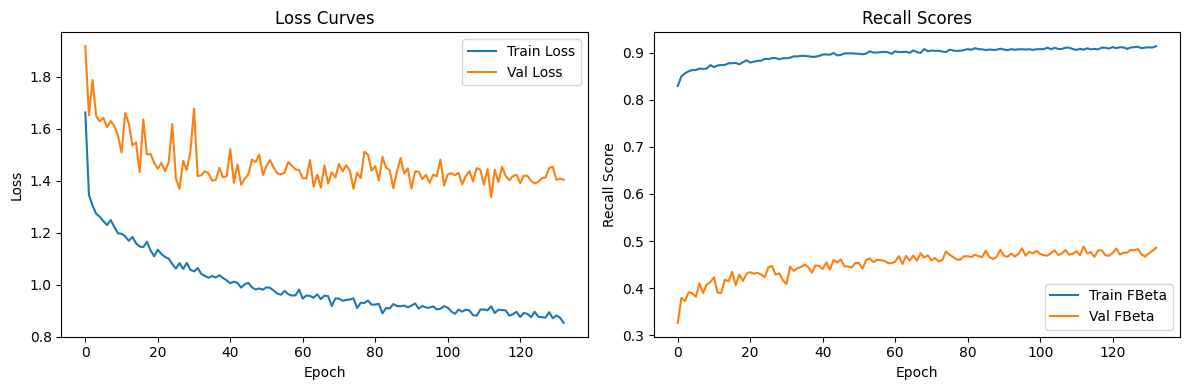


Final Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.58      0.73      6693
         1.0       0.17      0.90      0.29       643

    accuracy                           0.61      7336
   macro avg       0.58      0.74      0.51      7336
weighted avg       0.91      0.61      0.69      7336


Finale Evaluierung:
F1-Score: 0.2893
F2-Score: 0.4886
Balanced Accuracy: 0.7431
ROC-AUC: 0.8373


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇████
final_balanced_accuracy,▁
final_f1,▁
final_f2,▁
final_roc_auc,▁
train_loss,█▅▅▄▄▄▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val_aucpr,▄▃▆▇▆▃▆▆▆▄█▅▃▃▄▂▃▄▃▅▅▇▄▂▄▅▂▅▅▃▂█▆▂▁▃▇▅▄▄
val_f1,▁▁▂▁▄▄▄▅▅▅▆▅▆▅▆▆▆▆▇▇▇▆▇▆▆▆▇▇█▇▇▇█▇▇█▇▇▇█
val_f2,▁▃▃▅▄▆▆▆▅▇▇▇▆▇▇▇▇▇▇▇▇▇█▇▇▇▇▇▇▇██▇▇██▇███
val_loss,█▄▄▄▄▃▂▂▄▁▂▁▁▂▁▂▂▂▂▂▁▂▂▂▂▂▂▂▂▁▁▁▂▂▂▁▁▁▁▁
epoch,132


In [4]:
from sklearn.metrics import average_precision_score
import yaml

class BinaryClassifier(nn.Module):
    def __init__(self, input_features, config):
        super(BinaryClassifier, self).__init__()
        self.config = config

        layers = []
        current_size = input_features

        for hidden_size in self.config.hidden_layers:
            layers.extend([
                nn.Linear(current_size, hidden_size),
                nn.BatchNorm1d(hidden_size),
                nn.ReLU(),
                nn.Dropout(self.config.dropout_rate)
            ])
            current_size = hidden_size

        layers.append(nn.Linear(current_size, 1))
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

# Custom Loss Functions
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, inputs, targets):
        # Stelle sicher, dass beide Tensoren die gleiche Form haben
        inputs = inputs.view(-1)  # Flatten zu 1D
        targets = targets.view(-1)  # Flatten zu 1D
        
        bce_loss = F.binary_cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1-pt)**self.gamma * bce_loss
        return torch.mean(focal_loss)

class FocalLossWithSigmoid(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.focal = FocalLoss(alpha=alpha, gamma=gamma)

    def forward(self, inputs, targets):
        inputs = torch.sigmoid(inputs)   # Sigmoid hier
        return self.focal(inputs, targets)

class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05):
        super(AsymmetricLoss, self).__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip

    def forward(self, inputs, targets):
        targets = targets.view(-1, 1)
        inputs = torch.clamp(inputs, self.clip, 1 - self.clip)
        
        # Positive samples
        pt_pos = torch.where(targets == 1, inputs, torch.ones_like(inputs))
        loss_pos = -torch.log(pt_pos) * torch.pow(1 - pt_pos, self.gamma_pos) * targets
        
        # Negative samples
        pt_neg = torch.where(targets == 0, 1 - inputs, torch.ones_like(inputs))
        loss_neg = -torch.log(pt_neg) * torch.pow(1 - pt_neg, self.gamma_neg) * (1 - targets)
        
        return torch.mean(loss_pos + loss_neg)

class BCEWithSigmoid(nn.Module):
    def __init__(self):
        super().__init__()
        self.bce = nn.BCELoss()

    def forward(self, inputs, targets):
        inputs = torch.sigmoid(inputs)   # Sigmoid hier
        return self.bce(inputs, targets)

class AsymmetricLossWithSigmoid(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05):
        super().__init__()
        self.asl = AsymmetricLoss(gamma_neg=gamma_neg, gamma_pos=gamma_pos, clip=clip)

    def forward(self, inputs, targets):
        inputs = torch.sigmoid(inputs)   # Sigmoid hier
        return self.asl(inputs, targets)

class LLoss(nn.Module):
    def __init__(self, beta=1):
        super(LLoss, self).__init__()
        self.beta = beta
    
    def forward(self, inputs, targets):
        targets = targets.view(-1, 1)
        L = 1 + torch.pow(inputs - targets, 2)
        L = torch.log(L)
        return torch.mean(L)

class MLoss(nn.Module):
    def __init__(self, beta=1):
        super(MLoss, self).__init__()
        self.beta = beta
    
    def forward(self, inputs, targets):
        targets = targets.view(-1, 1)
        M = torch.abs(inputs - targets)
        M = 1 - torch.exp(-self.beta * M)
        return torch.mean(M)

# Loss Function Factory
def get_loss_function(loss_name):
    if loss_name == "BCE":
        return BCEWithSigmoid().to(device)
    elif loss_name == "BCEWithLogits":
        pos_weight = torch.tensor([(y_train == 0).sum() / (y_train == 1).sum()]).to(device)
        return nn.BCEWithLogitsLoss(pos_weight=pos_weight).to(device)
    elif loss_name == "Focal":
        return FocalLossWithSigmoid(
            alpha=wandb.config.loss_params["focal_alpha"],
            gamma=wandb.config.loss_params["focal_gamma"]
        ).to(device)
    elif loss_name == "Asymmetric":
        return AsymmetricLossWithSigmoid(
            gamma_neg=wandb.config.loss_params["asymmetric_gamma_neg"],
            gamma_pos=wandb.config.loss_params["asymmetric_gamma_pos"],
            clip=wandb.config.loss_params["asymmetric_clip"]
        ).to(device)
    elif loss_name == "L":
        return LLoss(beta=wandb.config.loss_params["l_beta"]).to(device)
    elif loss_name == "M":
        return MLoss(beta=wandb.config.loss_params["m_beta"]).to(device)
    else:
        raise ValueError(f"Unbekannte Loss-Funktion: {loss_name}")

def get_optimizer(model, optimizer_name):
    if optimizer_name == "AdamW":
        return torch.optim.AdamW(
            model.parameters(),
            lr=wandb.config.learning_rate,
            weight_decay=wandb.config.weight_decay
        )
    elif optimizer_name == "Adam":
        return torch.optim.Adam(
            model.parameters(),
            lr=wandb.config.learning_rate,
            weight_decay=wandb.config.weight_decay
        )
    elif optimizer_name == "RMSprop":
        return torch.optim.RMSprop(
            model.parameters(),
            lr=wandb.config.learning_rate,
            weight_decay=wandb.config.weight_decay
        )
    else:
        raise ValueError(f"Optimizer {optimizer_name} nicht unterstützt")

def train_epoch(model, train_loader, criterion, optimizer):
    model.train()
    total_loss = 0
    predictions = []
    true_labels = []
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs.squeeze(), y_batch)
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        predictions.extend((torch.sigmoid(outputs) > 0.5).squeeze().cpu().detach().numpy())
        true_labels.extend(y_batch.cpu().detach().numpy())
    
    # Berechne beide Metriken
    f1 = f1_score(true_labels, predictions)
    f2 = fbeta_score(true_labels, predictions, beta=2.0)
    
    return total_loss / len(train_loader), {"f1": f1, "f2": f2}

def calculate_recall_pos(all_targets, all_preds):
    return recall_score(all_targets, all_preds, pos_label=1)

def save_config_to_yaml(config, filename="best_model.yml"):
    """
    Speichert die Konfiguration in einer YAML-Datei.
    :param config: Die Konfiguration (z. B. wandb.config).
    :param filename: Der Name der Datei, in der die Konfiguration gespeichert werden soll.
    """
    with open(filename, "w") as file:
        yaml.dump(dict(config), file)

def evaluate(model, val_loader, criterion=None, is_final=False, is_test=False):
    model.eval()
    total_loss = 0
    all_preds = []
    all_targets = []
    all_probs = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            outputs = model(X_batch)
            if not is_final:
                loss = criterion(outputs.squeeze(), y_batch)
                total_loss += loss.item()
            
            probs = torch.sigmoid(outputs)
            preds = (probs > 0.5).float()
            
            all_preds.extend(preds.view(-1).cpu().numpy())
            all_targets.extend(y_batch.cpu().detach().numpy())
            all_probs.extend(probs.view(-1).cpu().numpy())
    
    # Berechne Metriken
    f1 = f1_score(all_targets, all_preds)
    f2 = fbeta_score(all_targets, all_preds, beta=2.0) 
    aucpr = average_precision_score(all_targets, all_probs)
    wandb.log({"val_aucpr": aucpr})

    
    if is_final:
        bacc = balanced_accuracy_score(all_targets, all_preds)
        auc = roc_auc_score(all_targets, all_probs)
        
        print('\nFinale Evaluierung:')
        print(f'F1-Score: {f1:.4f}')
        print(f'F2-Score: {f2:.4f}')  
        print(f'Balanced Accuracy: {bacc:.4f}')
        print(f'ROC-AUC: {auc:.4f}')
        
        if not is_test:
            wandb.log({
                "final_f1": f1,
                "final_f2": f2, 
                "final_balanced_accuracy": bacc,
                "final_roc_auc": auc
            })
        
        return f1, f2, bacc, auc  
    else:
        avg_loss = total_loss / len(val_loader)
        return avg_loss, {"f1": f1, "f2": f2}  


def train_model(model, train_loader, val_loader, epochs=None, patience=None):    
    epochs = epochs if epochs is not None else wandb.config.epochs
    patience = patience if patience is not None else wandb.config.early_stopping_patience
    
    criterion = get_loss_function(wandb.config.loss_function)
    optimizer = get_optimizer(model, wandb.config.optimizer)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    best_val_f2 = 0  
    patience_counter = 0
    
    train_losses = []
    val_losses = []
    train_f1s = []
    train_f2s = []
    val_f1s = []
    val_f2s = []  
    
    for epoch in range(epochs):
        train_loss, train_metrics = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_metrics = evaluate(model, val_loader, criterion, is_final=False)
        
        val_f1 = val_metrics["f1"]
        val_f2 = val_metrics["f2"]  
        
        print(f'Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val F1: {val_f1:.4f} | Val F2: {val_f2:.4f}')
        
        wandb.log({
            'epoch': epoch,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_f1': val_f1,
            'val_f2': val_f2 
        })
        
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_f1s.append(train_metrics["f1"])
        train_f2s.append(train_metrics["f2"])
        val_f1s.append(val_f1)
        val_f2s.append(val_f2)  
        
        # Modell-Speicherung basierend auf F2-Score
        if val_f2 > best_val_f2:  
            best_val_f2 = val_f2
            torch.save(model.state_dict(), 'best_model.pth')
            wandb.save('best_model.pth')
            save_config_to_yaml(wandb.config, filename="best_model.yml")
            print(f'Epoch {epoch:03d}: New best model saved with F2 = {val_f2:.4f}')
            patience_counter = 0
        else:
            patience_counter += 1

        
        if patience_counter >= patience:
            print(f'Early stopping at epoch {epoch}')
            break
    
    # Load best model
    model.load_state_dict(torch.load('best_model.pth'))
    
    # Plot training curves
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.title('Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(train_f2s, label='Train FBeta')
    plt.plot(val_f2s, label='Val FBeta')
    plt.title('Recall Scores')
    plt.xlabel('Epoch')
    plt.ylabel('Recall Score')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Final evaluation
    model.eval()
    predictions = []
    true_labels = []
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device) # Daten auf GPU laden
            outputs = model(X_batch)
            predictions.extend((torch.sigmoid(outputs) > 0.5).squeeze().cpu().numpy())
            true_labels.extend(y_batch.cpu().detach().numpy())
    
    print("\nFinal Classification Report:")
    print(classification_report(true_labels, predictions))
    
    return model

def prepare_data():
    # Build feature list dynamically
    feature_flags = {
        'audio_complexity': wandb.config.audio_complexity,
        'word_occurrence': wandb.config.word_occurrence,
        'word_complexity': wandb.config.word_complexity,
        'sentence_complexity': wandb.config.sentence_complexity,
        'word_importance': wandb.config.word_importance,
        'speed': wandb.config.speed,
        'ambient_volume': wandb.config.ambient_volume,
        'speech_volume': wandb.config.speech_volume,
        'frequency': wandb.config.frequency,
        'audio_level': wandb.config.audio_level,
        'language_level': wandb.config.language_level
    }
    
    features = [feat for feat, include in feature_flags.items() if include]
    if not features:  # Fallback if all features are disabled
        features = list(feature_flags.keys())
    
    # Use dynamic features
    X = df[features].values
    y = df['display'].astype(int).values
    
    # Rest of the existing prepare_data() code remains the same...
    global y_train, X_train
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Umwandeln in Tensoren, für Pytorch notwendig
    X_train = torch.FloatTensor(X_train).to(device) # Tensoren direkt auf GPU laden
    X_val = torch.FloatTensor(X_val).to(device) # Tensoren direkt auf GPU laden
    y_train = torch.FloatTensor(y_train).to(device) # Tensoren direkt auf GPU laden
    y_val = torch.FloatTensor(y_val).to(device) # Tensoren direkt auf GPU laden
    
    train_dataset = TensorDataset(X_train, y_train) # TensorDataset, simpler als Dataset
    val_dataset = TensorDataset(X_val, y_val)

    global train_loader
    # Gewichtetes Sampling für unbalancierte Klassen
    if wandb.config.weighted_sampler:
        class_counts = np.bincount(y_train.int().cpu().numpy()) # .int() für Datentype int32, .numpy() für Numpy-Array, bincount für Klassenverteilung (bei [0, 1, 1, 2, 2, 2] = [1, 2, 3])
        # [3771  317]
        weights = 1.0 / torch.tensor(class_counts, dtype=torch.float) # Klassen werden je nach Anzahl in Trainingsdaten gewichtet
        # 1 / tensor([3771.,  317.]) > tensor([0.0003, 0.0032])
        samples_weights = weights[y_train.int().cpu()] # Gewichtung für jedes Sample, also false * 0.0003 und true * 0.0032 > damit hat true höhere P gezogen zu werden

        sampler = WeightedRandomSampler(
            weights=samples_weights,
            num_samples=len(samples_weights),
            replacement=True # Mit replacement=True können die wenigen Samples der Minderheitsklasse mehrfach verwendet werden, bei false wäre gewichtetes Sampling nicht möglich
        )

        # DataLoader mit Weighted Sampler
        train_loader = DataLoader(
            train_dataset,
            batch_size=wandb.config.batch_size,
            sampler=sampler,
            drop_last=True 
        )
    else:
        # DataLoader ohne Weighted Sampling
        train_loader = DataLoader(
            train_dataset,
            batch_size=wandb.config.batch_size,
            shuffle=True,
            drop_last=True 
        )

    global val_loader
    # Validation DataLoader (ohne Weighted Sampling, da nur für Evaluierung)
    val_loader = DataLoader(val_dataset, batch_size=wandb.config.batch_size, shuffle=False, drop_last=True) # Shuffle beim Validieren nicht notwendig



def start_training():
    # Überprüfen, ob eine GPU verfügbar ist
    global device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f'Using device: {device}')

    # Wandb Initialisierung
    wandb.init(
        project="Intelligent Subtitles Advanced",
        config={
            "learning_rate": 0.004252027091067649,
            "architecture": "MLP",
            "dataset": "3boys",
            "epochs": 150,
            "batch_size": 1048,
            "optimizer": "AdamW",  # Wählen Sie zwischen 'AdamW', 'Adam', 'RMSprop'
            "weight_decay": 0.0344653149484944,
            "loss_function": "BCEWithLogits",  # Choices: ['BCE', 'BCEWithLogits', 'Focal', 'Asymmetric', 'L', 'M']
            "loss_params": {
                "focal_alpha": 1,
                "focal_gamma": 2,
                "asymmetric_gamma_neg": 4,
                "asymmetric_gamma_pos": 1,
                "asymmetric_clip": 0.05,
                "l_beta": 1,
                "m_beta": 1
            },
            "weighted_sampler": True,
            "hidden_layers": [64, 128, 128, 64],
            "dropout_rate": 0.14279874595232844,
            "early_stopping_patience": 20,
            "beta_score": 2.0,
            'audio_complexity': True,
            'word_occurrence': True,
            'word_complexity': True,
            'sentence_complexity': True,
            'word_importance': True,
            'speed': True,
            'ambient_volume': True,
            'speech_volume': True,
            'frequency': True,
            'audio_level': True,
            'language_level': True,
        }
    )

    # Daten vorbereiten
    prepare_data()

    # Train model
    num_features = X_train.shape[1]
    model = BinaryClassifier(input_features=num_features, config=wandb.config) 
    model = model.to(device)
    train_model(model, train_loader, val_loader)

    # Final evaluation
    model.load_state_dict(torch.load('best_model.pth'))
    criterion = get_loss_function(wandb.config.loss_function)
    model.eval()
    evaluate(model, val_loader, criterion, is_final=True, is_test=False)
    wandb.finish()


start_training()

### Sweep

In [ ]:
sweep_config = {
    'method': 'bayes', 
    'metric': {
        'name': 'val_f2',  
        'goal': 'maximize'
    },
    'parameters': {
        'learning_rate': {'min': 0.0001, 'max': 0.01},
        'batch_size': {'values': [16, 32, 64, 128, 256, 512, 1024]},
        'optimizer': {
            'values': ['AdamW', 'Adam', 'RMSprop']
        },
        'weight_decay': {
            'min': 0.001,
            'max': 0.1
        },
        'loss_function': {
            'values': ['BCE', 'BCEWithLogits', 'Focal', 'Asymmetric']
        },
        'weighted_sampler': {
            'values': [True, False]
        },
        'hidden_layers': {
            'values': [
                [64, 32, 16],
                [128, 64, 32],
                [256, 128, 64],
                [64, 128, 64],
                [8, 16, 32, 16, 8],
                [16, 32, 64, 32, 16],
                [32, 64, 128, 64, 32],
                [64, 128, 256, 128, 64],
                [128, 256, 512, 256, 128],
                [256, 512, 1024, 512, 256]
            ]
        },
        'dropout_rate': {
            'min': 0.1,
            'max': 0.8
        },
        'epochs': {
            'value': 200 
        },
        'early_stopping_patience': {
            'value': 20  # Increased patience for stable convergence
        },
        'audio_complexity': {'values': [True]},
        'word_occurrence': {'values': [True]},
        'word_complexity': {'values': [True]},
        'sentence_complexity': {'values': [True]},
        'word_importance': {'values': [True]},
        'speed': {'values': [True]},
        'ambient_volume': {'values': [True]},
        'speech_volume': {'values': [True]},
        'frequency': {'values': [True]},
        'audio_level': {'values': [True]},
        'language_level': {'values': [True]}
    }
}

def start_training():
    # Set up the device
    global device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f'Using device: {device}')

    # Initialize wandb and use the sweep configuration
    wandb.init(project="Intelligent Subtitles Level")
    
    # Prepare data using the updated prepare_data() that picks features from wandb.config
    prepare_data()  # This should set up the global train_loader and val_loader as well as X_train, etc.
    num_features = X_train.shape[1]
    
    # Instantiate the model using hyperparameters from wandb.config
    model = BinaryClassifier(input_features=num_features, config=wandb.config)
    model = model.to(device)
    
    # Train the model; the train_model function now receives the proper arguments
    trained_model = train_model(model, train_loader, val_loader)
    
    # Optionally perform final evaluation
    criterion = get_loss_function(wandb.config.loss_function)
    trained_model.eval()
    evaluate(trained_model, val_loader, criterion, is_final=True, is_test=False)
    
    # Finish the wandb run
    wandb.finish()

# Launch the sweep using the wrapper function that takes no arguments
project_name = "Intelligent Subtitles Level3"
sweep_id = wandb.sweep(sweep_config, project=project_name)
wandb.agent(sweep_id, function=start_training, count=100)

### Evaluieren

In [ ]:
import wandb
from xgboost import XGBClassifier
from sklearn.metrics import fbeta_score, classification_report
import pandas as pd

# 1. Fetch the run from W&B
run_path = 
api = wandb.Api()
run = api.run(run_path)

# 2. Load the model artifact
model_artifact = run.logged_artifacts()[0]  # Get first artifact
model_dir = model_artifact.download()
model = XGBClassifier()
model.load_model(f"{model_dir}/model.json")

# 3. Prepare evaluation data (modify with your actual test data)
X_test = df[run.config["features_used"]]  # Use only the features used in this run
y_test = df["display"]

# 4. Evaluate
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Calculate metrics
f2 = fbeta_score(y_test, y_pred, beta=2)
aucpr = average_precision_score(y_test, y_proba)

# Log evaluation to new W&B run
with wandb.init(project="XGBoost-Evaluation") as eval_run:
    eval_run.config.update(run.config)
    
    wandb.log({
        "test_f2": f2,
        "test_aucpr": aucpr,
        "classification_report": classification_report(y_test, y_pred, output_dict=True)
    })


In [ ]:
from types import SimpleNamespace
api = wandb.Api()
run = 
wandb.config = SimpleNamespace(**run.config)

run.file("best_model.pth").download(replace=True)
import yaml

# Load configuration
with open("best_model.yml", "r") as file:
    config = yaml.safe_load(file)

config = SimpleNamespace(**config)

# Modell laden
model = BinaryClassifier(input_features=11, config=config).to(device)
model.load_state_dict(torch.load('best_model.pth', map_location=device))
model.eval()

# Evaluierung durchführen
evaluate(model, val_loader, is_final=True, is_test=True)

predictions = []
true_labels = []
with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device) # Daten auf GPU laden
        outputs = model(X_batch)
        predictions.extend((torch.sigmoid(outputs) > 0.5).squeeze().cpu().numpy())
        true_labels.extend(y_batch.cpu().numpy())

print("\nFinal Classification Report:")
print(classification_report(true_labels, predictions))


Final Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.65      0.78      5691
         1.0       0.21      0.87      0.33       597

    accuracy                           0.67      6288
   macro avg       0.59      0.76      0.56      6288
weighted avg       0.91      0.67      0.74      6288

